# Telco Customer Churn Analysis

This explores customer data to understand the factors driving churn and implements various machine learning models—ranging from linear regression to classification and clustering—to predict customer behavior and segment the user base.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
df=pd.read_csv("/content/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Preparing the Data

Before diving into analysis, we need to ensure the data is in the right format. We'll convert the total charges to a numeric format, handle any missing entries that arise from that conversion, and remove the customer ID since it won't help us with the predictive modeling.

In [28]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# We use errors='ignore' so the code doesn't crash if the column was already removed
df.drop('customerID', axis=1, inplace=True, errors='ignore')

print("Shape after initial preprocessing:", df.shape)
display(df.head())

Shape after initial preprocessing: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## Exploratory Data Analysis (EDA)

Let's explore the dataset to understand its structure, distributions, and identify potential patterns.

In [6]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-nul

In [7]:
print("\nDescriptive Statistics for Numerical Columns:")
display(df.describe())


Descriptive Statistics for Numerical Columns:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00,7032.00
mean,0.16,32.42,64.80,2283.30
std,0.37,24.55,30.09,2266.77
min,0.00,1.00,18.25,18.80
25%,0.00,9.00,35.59,401.45
50%,0.00,29.00,70.35,1397.47
75%,0.00,55.00,89.86,3794.74
max,1.00,72.00,118.75,8684.80


In [8]:
print("\nMissing values after preprocessing:")
display(df.isnull().sum()[df.isnull().sum() > 0])


Missing values after preprocessing:


,0


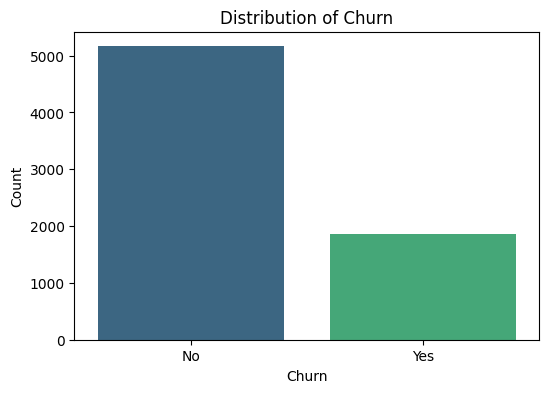

Churn Distribution:
Churn
No    0.73
Yes   0.27
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

print("Churn Distribution:")
print(df['Churn'].value_counts(normalize=True))


Analyzing Categorical Features vs Churn:


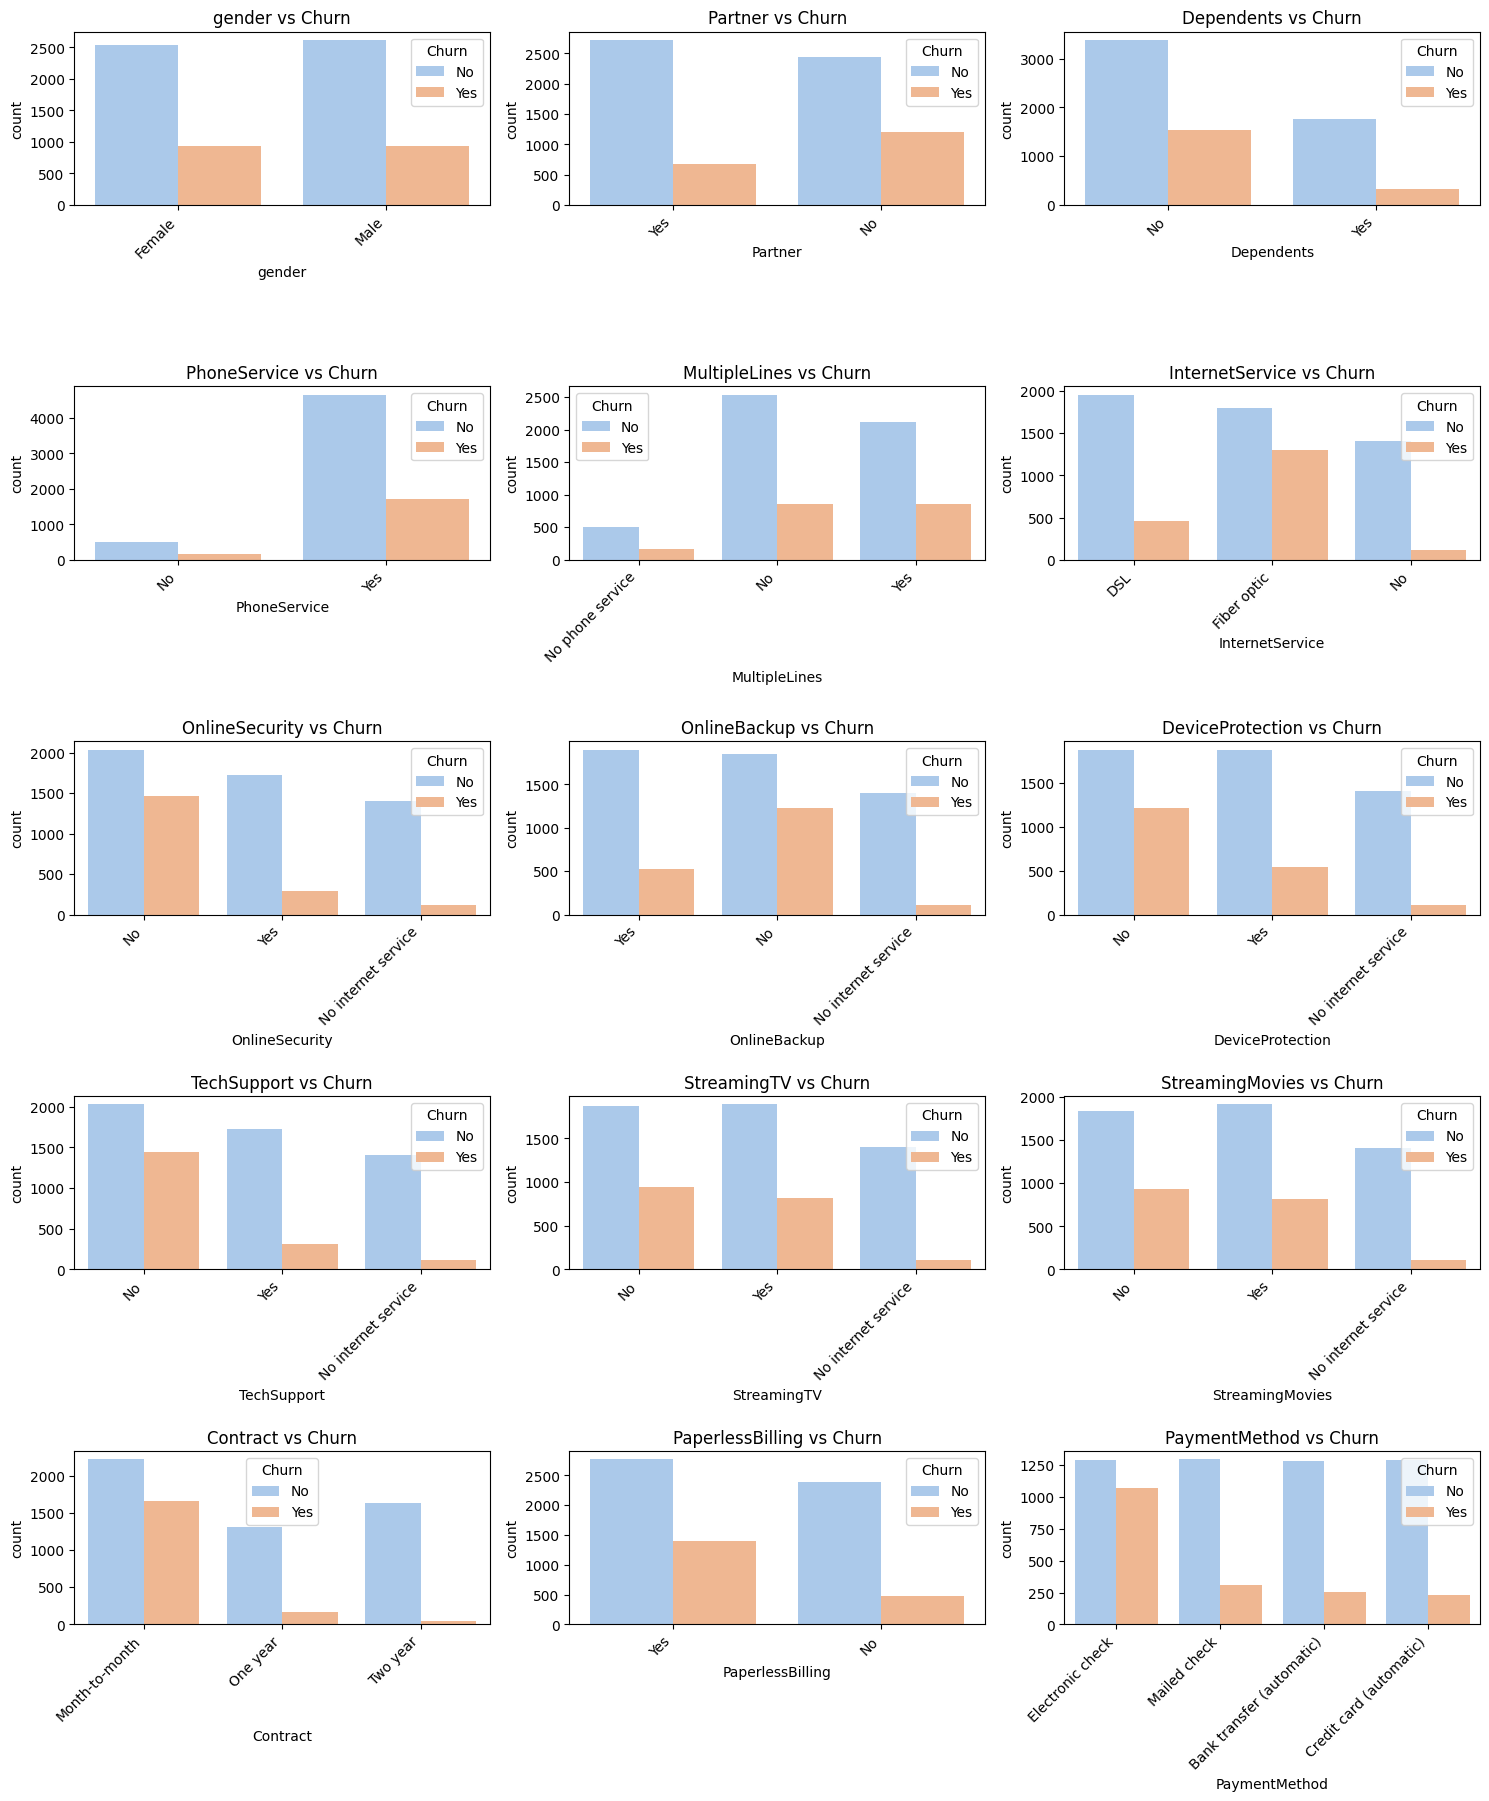

In [10]:
print("\nAnalyzing Categorical Features vs Churn:")

categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn') # Exclude target variable

plt.figure(figsize=(15, 20))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(6, 3, i) # Adjust grid size as needed
    sns.countplot(x=col, hue='Churn', data=df, palette='pastel')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Analyzing Numerical Features vs Churn:


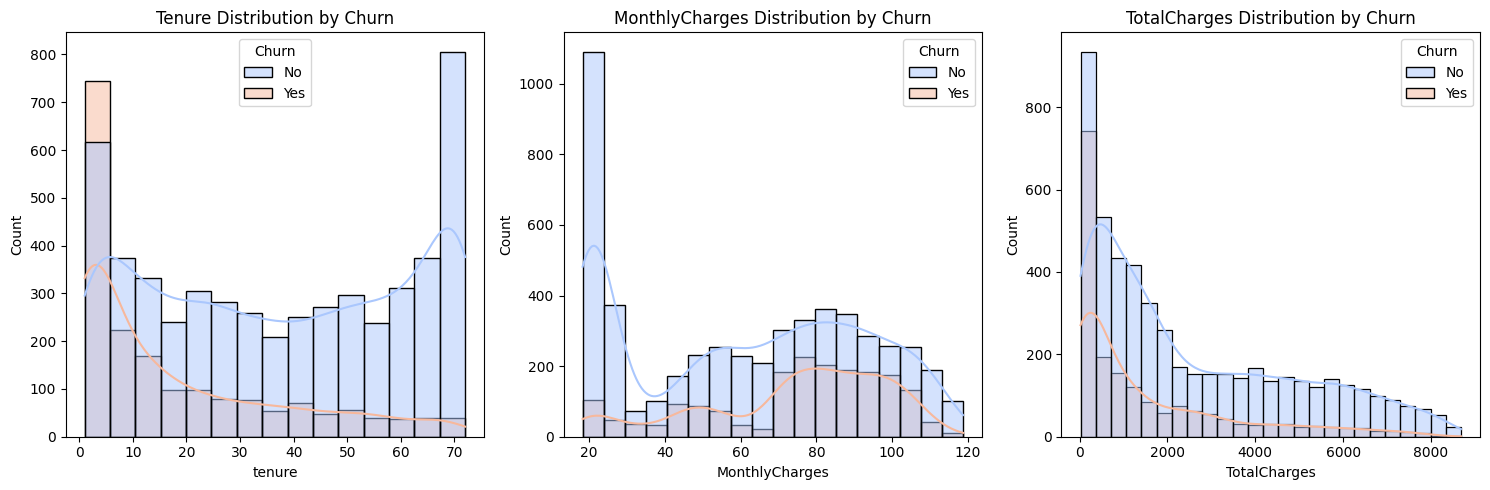

In [11]:
print("\nAnalyzing Numerical Features vs Churn:")

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('SeniorCitizen') # Often treated as categorical

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, palette='coolwarm')
plt.title('Tenure Distribution by Churn')

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, palette='coolwarm')
plt.title('MonthlyCharges Distribution by Churn')

plt.subplot(1, 3, 3)
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, palette='coolwarm')
plt.title('TotalCharges Distribution by Churn')

plt.tight_layout()
plt.show()

### Multiple Linear Regression

In this section, we'll examine how tenure and monthly charges together influence the total cost. We'll split the data to ensure we can test our model's accuracy on unseen information, then train the regression model and evaluate its precision using standard metrics like R-squared and Mean Squared Error.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X_mlr = df[['tenure', 'MonthlyCharges']]
y_mlr = df['TotalCharges']

X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(X_mlr, y_mlr, test_size=0.2, random_state=42)

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_mlr, y_train_mlr)

y_pred_mlr = lin_reg_model.predict(X_test_mlr)

r_squared = r2_score(y_test_mlr, y_pred_mlr)
mse = mean_squared_error(y_test_mlr, y_pred_mlr)

print(f"R-squared: {r_squared:.2f}")
print(f"MSE: {mse:.2f}")

R-squared: 0.90
MSE: 514283.50


### Simple Linear Regression

To better understand the direct relationship between how long a customer stays and their total charges, we'll build a simpler model using only tenure as a predictor. This helps us visualize the baseline trend in the data.

R-squared: 0.69


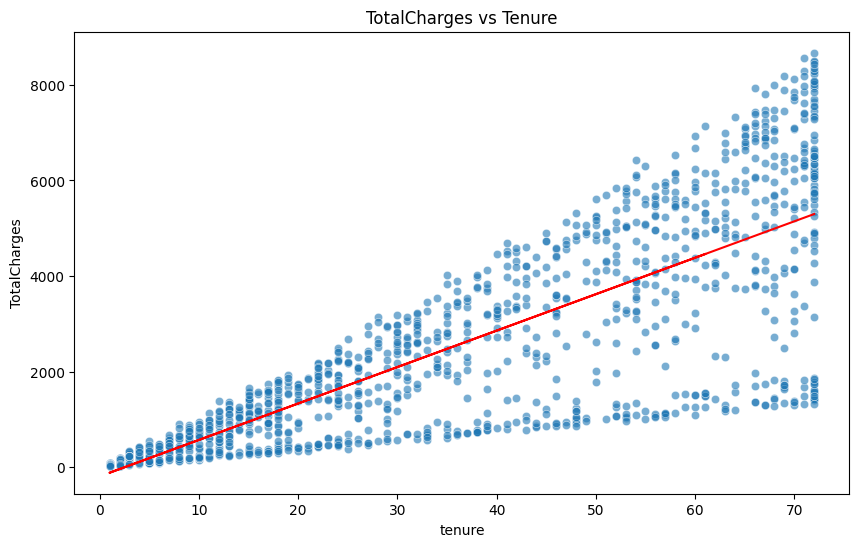

In [24]:
X_slr = df[['tenure']]
y_slr = df['TotalCharges']

X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(X_slr, y_slr, test_size=0.2, random_state=42)

slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train_slr)

y_pred_slr = slr_model.predict(X_test_slr)

r_squared_slr = r2_score(y_test_slr, y_pred_slr)
mse_slr = mean_squared_error(y_test_slr, y_pred_slr)

print(f"R-squared: {r_squared_slr:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_slr['tenure'], y=y_test_slr, alpha=0.6)
plt.plot(X_test_slr['tenure'], y_pred_slr, color='red')
plt.title('TotalCharges vs Tenure')
plt.show()

### Predicting Customer Churn with Logistic Regression

To predict whether a customer is likely to leave, we need to handle a mix of categorical and numerical data. We'll use a specialized pipeline to scale numbers and encode categories properly. Because the dataset has fewer examples of customers leaving, we'll also use SMOTE to balance the classes, giving the model a better chance to learn patterns for both outcomes.

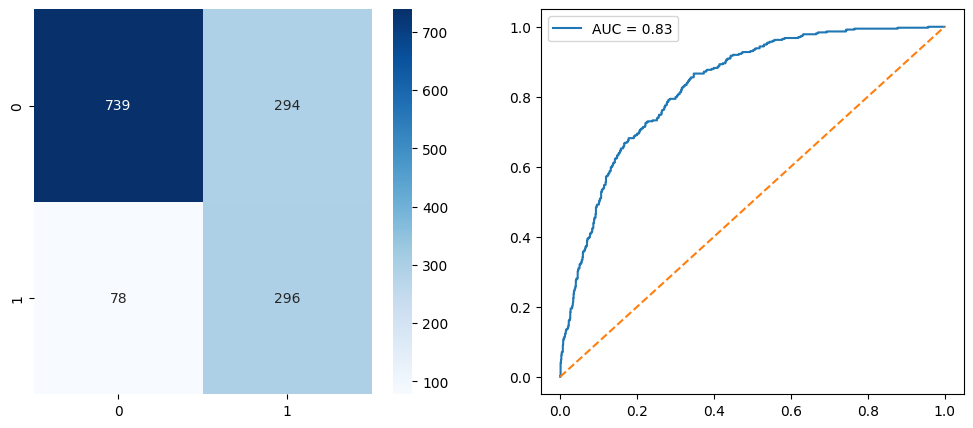

In [25]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

df_churn = df.copy()

if df_churn['Churn'].dtype == 'object':
    df_churn['Churn'] = df_churn['Churn'].map({'Yes': 1, 'No': 0})

df_churn.dropna(subset=['Churn'], inplace=True)

X = df_churn.drop('Churn', axis=1)
y = df_churn['Churn'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

categorical_features = X_train.select_dtypes(include=['object']).columns
numerical_features = X_train.select_dtypes(include=np.number).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train_resampled, y_train_resampled)

y_pred_lr = log_reg_model.predict(X_test_processed)
y_pred_proba_lr = log_reg_model.predict_proba(X_test_processed)[:, 1]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], '--')
plt.legend()
plt.show()

### Comparing with Naive Bayes

As a point of comparison, we'll apply a Naive Bayes classifier to the same data. This helps us see if a different algorithmic approach yields better results for identifying potential churn.

In [26]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
gnb_model.fit(X_train_resampled, y_train_resampled)

y_pred_gnb = gnb_model.predict(X_test_processed)

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Naive Bayes Report:\n", classification_report(y_test, y_pred_gnb))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407

Naive Bayes Report:
               precision    recall  f1-score   support

           0       0.89      0.71      0.79      1033
           1       0.49      0.76      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.78      0.72      0.74      1407



### Discovering Customer Segments

Finally, we'll use unsupervised learning to see if customers naturally group together based on their tenure and spending habits. We'll use the elbow method to find the most logical number of groups and then visualize these distinct customer segments.

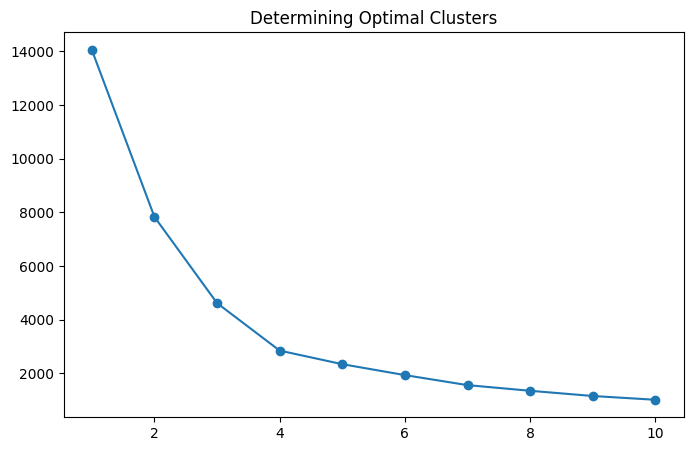

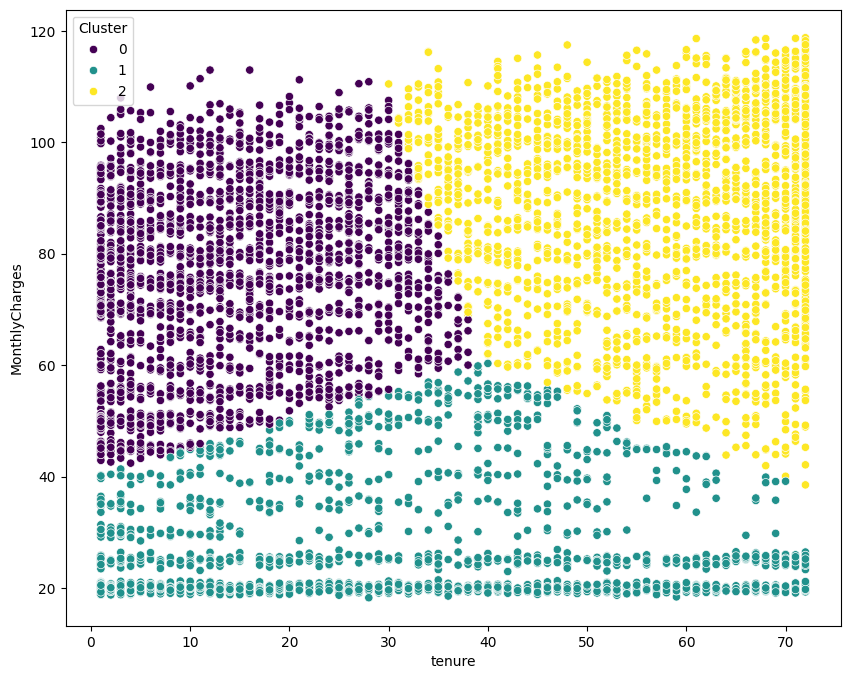

In [27]:
from sklearn.cluster import KMeans

X_kmeans = df[['tenure', 'MonthlyCharges']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kmeans)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Determining Optimal Clusters')
plt.show()

kmeans_model = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X_scaled)
X_kmeans['Cluster'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(data=X_kmeans, x='tenure', y='MonthlyCharges', hue='Cluster', palette='viridis')
plt.show()

In [16]:
df.shape

(7032, 20)